# Ridgeline Plot

This section showcases the ridgeline plot. It contains examples of how to create ridgeline plots using the [datachart.charts.RidgelinePlot](../../../references/charts/#datachart.charts.RidgelinePlot) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-ridgeline-plot), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the ridgeline plots are created using the `RidgelinePlot` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import RidgelinePlot

## Ridgeline Plot Input Attributes

The `RidgelinePlot` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the data points. For a single ridgeline plot, `data` is a list of dictionaries; the points that share a `label` form one row. For multiple ridgeline plots, `data` is a list of lists, and each chart draws in its own subplot.

```python
RidgelinePlot(
    data=[{                                             # A list of data points (or list of lists for multiple charts)
        "label": str,                                   # The row label
        "value": Union[int, float],                     # The numeric value
    }],
    style={                                             # The style of the ridges (optional)
        "plot_ridgeline_color":           Union[str, None],         # The ridge fill color
        "plot_ridgeline_alpha":           Union[float, None],       # The alpha of the ridge fill
        "plot_ridgeline_linewidth":       Union[int, float, None],  # The line width of the outline
        "plot_ridgeline_edgecolor":       Union[str, None],         # The outline color
        "plot_ridgeline_overlap":         Union[float, None],       # The default row overlap
        "plot_ridgeline_inner_color":     Union[str, None],         # The color of the inner marks
        "plot_ridgeline_inner_linewidth": Union[int, float, None],  # The line width of the inner marks
    },
    title: Union[str, None],                            # The chart title (optional)
    xlabel: Union[str, None],                           # The x-axis label (optional)
    ylabel: Union[str, None],                           # The y-axis label (optional)
    subtitle: Union[str, List[str], None],              # The subtitle(s), used as subplot titles (optional)
    emphasis: Union[str, List[str], None],              # The emphasis role(s), aligned with the row labels (optional)
    emphasis_rule=Optional[dict],                       # One-key rule on a per-row summary; optional "by": median, mean, min, max, sum
    overlap: Union[float, None],                        # How far a peak rises into the row above, in [0, 1] (optional)
    normalize: Union[str, None],                        # "per_row" (the default) or "common" (optional)
    inner: Union[str, None],                            # "median", "quartiles", or None (the default) (optional)
    fill: bool,                                         # Whether to fill the ridges (optional)
    show_outline: bool,                                 # Whether to stroke the ridge curves (optional)
    sort: Union[str, None],                             # None, "ascending", or "descending" by median (optional)
    bandwidth: Union[str, float, None],                 # The KDE bandwidth rule or factor (optional)
    orientation: Union[str, None],                      # "horizontal" (the default) or "vertical" (optional)
    scaley: Union[str, None],                           # The value axis scale (optional)
    figsize: Union[Tuple[float, float], None],          # The figure size (optional)
    show_grid: Union[str, None],                        # Which grid lines to show (optional)
    xmin: Union[int, float, None],                      # The minimum x-axis value; bounds the density grid (optional)
    xmax: Union[int, float, None],                      # The maximum x-axis value; bounds the density grid (optional)
    subplots: Union[bool, None],                        # Whether to draw each chart in its own subplot (optional)
    max_cols: Union[int, None],                         # The maximum number of subplot columns (optional)
    sharex: Union[bool, None],                          # Whether the subplots share the x-axis (optional)
    sharey: Union[bool, None],                          # Whether the subplots share the y-axis (optional)
    hlines: Union[dict, List[dict], None],              # The horizontal reference lines (optional)
    vlines: Union[dict, List[dict], None],              # The vertical reference lines (optional)
    vspans: Union[dict, List[dict], None],              # The vertical reference bands (optional)
    hspans: Union[dict, List[dict], None],              # The horizontal reference bands (optional)
    label: Union[str, None],                            # The key name in `data` holding the label (optional)
    value: Union[str, None],                            # The key name in `data` holding the value (optional)
)
```

For more details, see the [datachart.charts.RidgelinePlot](../../../references/charts/#datachart.charts.RidgelinePlot) function.

## Basics

The examples in this guide share one dataset: a year of daily mean temperatures in Ljubljana. Each month's thirty days are drawn around that month's 1991–2020 climate normal, with the day-to-day spread wider in winter than in summer; the data is computed in a hidden cell with a fixed seed. `chart_data` holds one data point per day, labeled with its month, so the twelve months give twelve ridges.

In [2]:
import numpy as np

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C (1991-2020 normals of Ljubljana) and the day-to-day spread
MONTHLY_MEAN = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
MONTHLY_SPREAD = [4.0, 4.0, 3.5, 3.0, 2.5, 2.5, 2.5, 2.5, 3.0, 3.5, 3.5, 4.0]

rng = np.random.RandomState(11)
chart_data = [
    {"label": month, "value": round(float(temperature), 1)}
    for month, mean, spread in zip(MONTHS, MONTHLY_MEAN, MONTHLY_SPREAD)
    for temperature in rng.normal(mean, spread, 30)
]

The data is a flat list of dictionaries, one per data point, each with a `label` and a `value`. The points that share a `label` form one row:

In [3]:
chart_data[:3]

[{'label': 'Jan', 'value': 7.8},
 {'label': 'Jan', 'value': -0.3},
 {'label': 'Jan', 'value': -1.1}]

**Basic example.** Only the `data` argument is required to draw the ridgeline plot. Every label draws one **ridge**, the density of its values, on its own row: the rows follow the order the labels first appear in the data, the first at the top, and each ridge rises from its row's tick into the row above it. Later rows draw over earlier ones, so the overlap reads as depth.

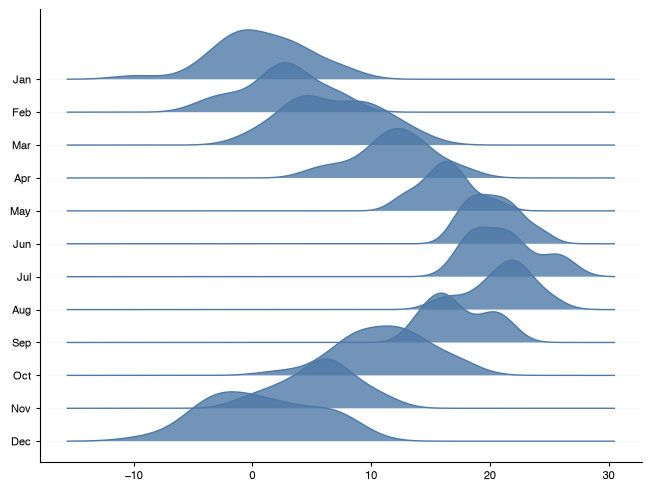

In [4]:
RidgelinePlot(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Ridgeline Plot

Every customization is either a keyword argument of `RidgelinePlot` or an attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                     | See |
| :------------------------------------------ | :------------------------------------------------------ | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure or show the grid          | `figsize`, `show_grid`                                  | [Figure size and grid](#figure-size-and-grid) |
| change the ridge fill, outline, or alpha    | `style={"plot_ridgeline_color": ...}`                 | [Ridge style](#ridge-style) |
| make the rows overlap more or less          | `overlap`                                               | [Row overlap](#row-overlap) |
| compare the ridge heights, not only shapes  | `normalize`                                             | [Ridge scale](#ridge-scale) |
| mark the median or the quartiles            | `inner`                                                 | [Inner marks](#inner-marks) |
| draw only the outlines or only the fills    | `fill`, `show_outline`                                  | [Fill and outline](#fill-and-outline) |
| order the rows by their median              | `sort`                                                  | [Row order](#row-order) |
| smooth or sharpen the ridges                | `bandwidth`                                             | [Bandwidth](#bandwidth) |
| fix the value range of the ridges           | `xmin`, `xmax`                                          | [Value range](#value-range) |
| stack the rows along the x-axis             | `orientation`                                           | [Orientation](#orientation) |
| highlight one row, mute the rest            | `emphasis`, `emphasis_rule`                             | [Emphasis](#emphasis) |
| draw a threshold or reference line          | `vlines`, `vspans`                                      | [Reference lines](#reference-lines) |
| draw each dataset in its own subplot        | `data` as a list of lists, `subplots`, `sharex`         | [Multiple Ridgeline Plots](#multiple-ridgeline-plots) |
| compose the ridgeline with other charts     | `Panel`, `Grid`                                         | [Composing ridgelines](#composing-ridgelines) |
| save the chart to a file                    | `save_figure`                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.RidgelineStyleAttrs](../../../references/typings/#datachart.typings.RidgelineStyleAttrs) type; the full list of parameters is in the [datachart.charts.RidgelinePlot](../../../references/charts/#datachart.charts.RidgelinePlot) reference.

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes. The value axis is the x-axis and the rows stack along the y-axis.

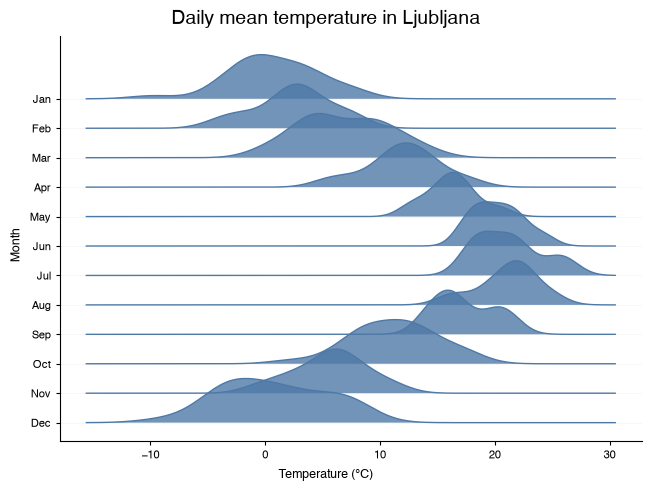

In [5]:
RidgelinePlot(
    data=chart_data,
    # add the title
    title="Daily mean temperature in Ljubljana",
    # add the x and y axis labels
    xlabel="Temperature (°C)",
    ylabel="Month",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To show the grid lines, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant. The ridges carry no legend entries: their labels are already on the row axis.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

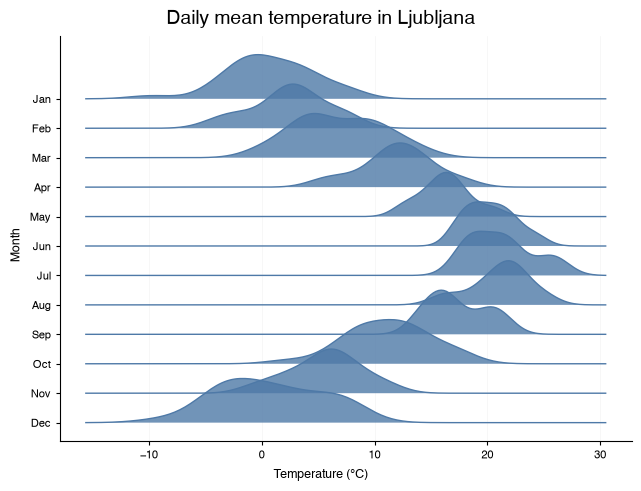

In [7]:
RidgelinePlot(
    data=chart_data,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    ylabel="Month",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_MEDIUM,
    # add to show the grid lines along the value axis
    show_grid=SHOW_GRID.X,
).show()

### Ridge style

To change the style of the ridges, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.RidgelineStyleAttrs](../../../references/typings/#datachart.typings.RidgelineStyleAttrs) type:

| Attribute | Description |
| :-------- | :---------- |
| `plot_ridgeline_color` | The ridge fill color; the palette color by default. |
| `plot_ridgeline_alpha` | The alpha of the fill; the outline stays opaque. |
| `plot_ridgeline_linewidth` | The line width of the outline. |
| `plot_ridgeline_edgecolor` | The outline color; the fill color by default. |
| `plot_ridgeline_overlap` | The row overlap used when `overlap` is not passed. |
| `plot_ridgeline_inner_color` | The color of the inner marks; the theme's font color by default. |
| `plot_ridgeline_inner_linewidth` | The line width of the inner marks. |

A white outline over an opaque fill is the classic joy plot look: every ridge cuts cleanly into the row behind it.

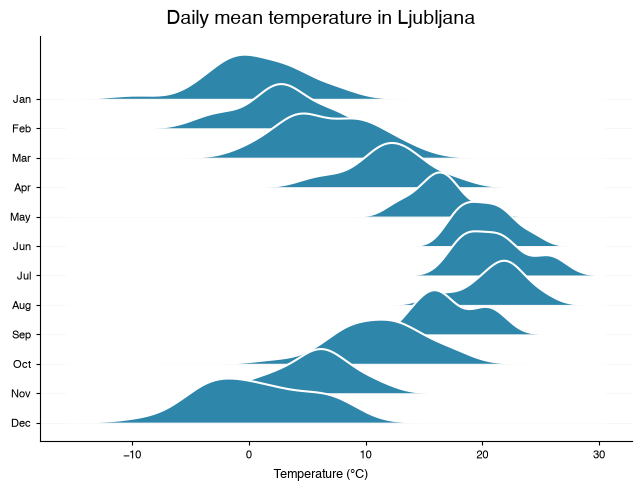

In [8]:
RidgelinePlot(
    data=chart_data,
    # define the style of the ridges
    style={
        "plot_ridgeline_color": "#2E86AB",
        "plot_ridgeline_alpha": 1.0,
        "plot_ridgeline_edgecolor": "#FFFFFF",
        "plot_ridgeline_linewidth": 1.5,
    },
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Row overlap

The `overlap` attribute sets how far each ridge rises into the row above it, as a number between 0 and 1: each ridge rises from its row's tick, and its peak stands `1 + overlap` rows above it. `0` makes the peaks just touch the next row, `1` sends them a whole row further. Without it the theme's `plot_ridgeline_overlap` applies (`0.5` in the predefined themes). Values outside `[0, 1]` raise a `ValueError`.

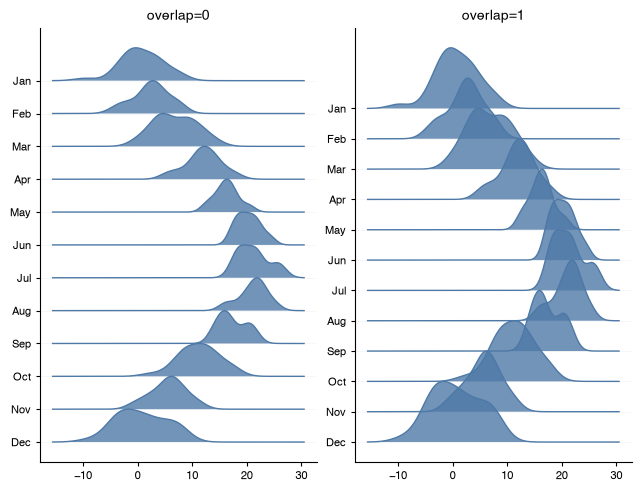

In [9]:
from datachart.utils import Grid

Grid(
    [
        RidgelinePlot(data=chart_data, overlap=0.0, title="overlap=0"),
        RidgelinePlot(data=chart_data, overlap=1.0, title="overlap=1"),
    ],
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Ridge scale

The `normalize` attribute chooses how the ridges are scaled. It supports the values of the [datachart.constants.RIDGELINE_SCALE](../../../references/constants/#datachart.constants.RIDGELINE_SCALE) constant:

| Value | Description |
| :---- | :---------- |
| `"per_row"` | Every ridge reaches the same peak height, so the shapes compare (the default). |
| `"common"` | All ridges share one density scale: the tallest ridge reaches the peak height and the others stay in proportion, so a wide, flat distribution draws lower than a narrow one. |

With a common scale the narrow summer months stand out as tall ridges and the variable winter months flatten.

In [10]:
from datachart.constants import RIDGELINE_SCALE

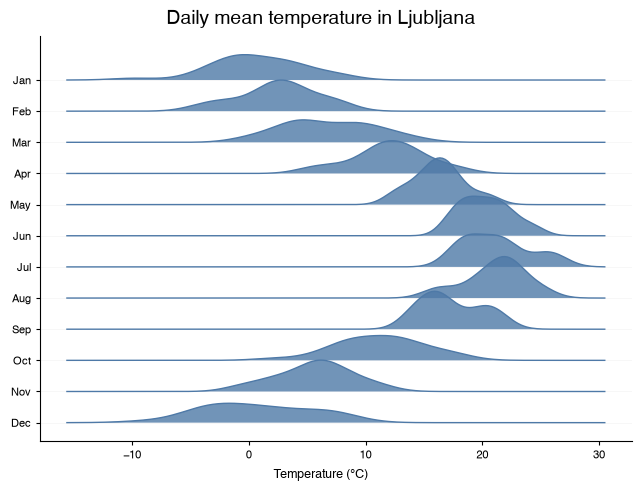

In [11]:
RidgelinePlot(
    data=chart_data,
    # one density scale for every ridge
    normalize=RIDGELINE_SCALE.COMMON,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Inner marks

The `inner` attribute draws marks inside each ridge, from its baseline up to the ridge height at that value. It takes the values of the [datachart.constants.VIOLIN_INNER](../../../references/constants/#datachart.constants.VIOLIN_INNER) constant, without `"box"`:

| Value | Description |
| :---- | :---------- |
| `"median"` | One solid line at the median. |
| `"quartiles"` | A dashed median line and dotted first and third quartile lines. |
| `None` | No marks (the default). |

In [12]:
from datachart.constants import VIOLIN_INNER

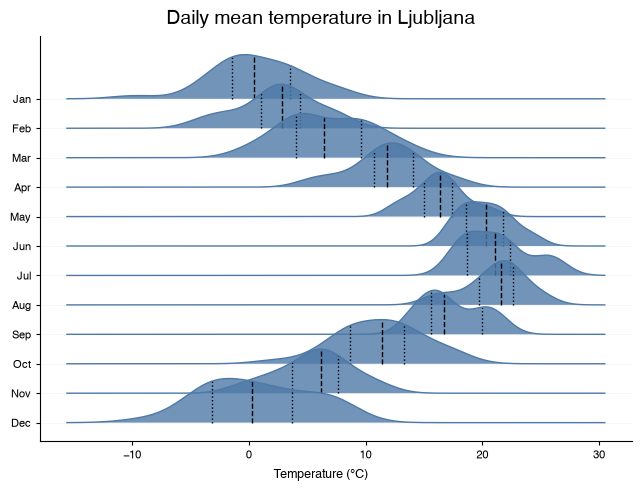

In [13]:
RidgelinePlot(
    data=chart_data,
    # mark the quartiles of every month
    inner=VIOLIN_INNER.QUARTILES,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Fill and outline

The `fill` and `show_outline` attributes turn the ridge fill and the density curve on and off independently; both are on by default. Outlines alone keep every row visible through the overlap. Turning both off raises a `ValueError`, since nothing would be drawn.

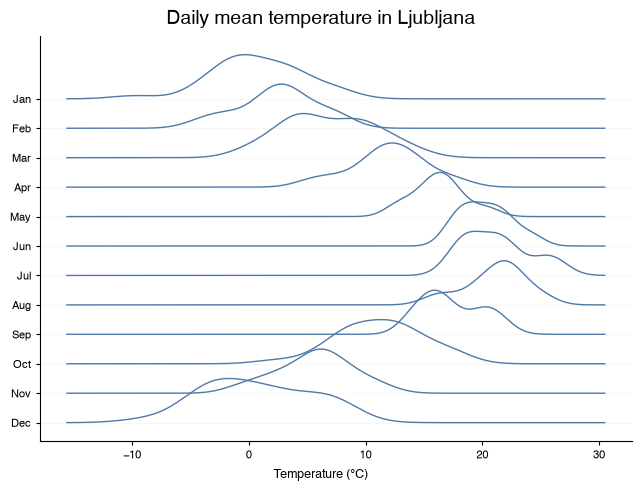

In [14]:
RidgelinePlot(
    data=chart_data,
    # draw only the density curves
    fill=False,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Row order

The rows follow the order the labels first appear in the data. The `sort` attribute orders them by their median instead, with the values of the [datachart.constants.SORT](../../../references/constants/#datachart.constants.SORT) constant: `"ascending"` puts the smallest median at the top, `"descending"` the largest. Rows with the same median keep their input order.

In [15]:
from datachart.constants import SORT

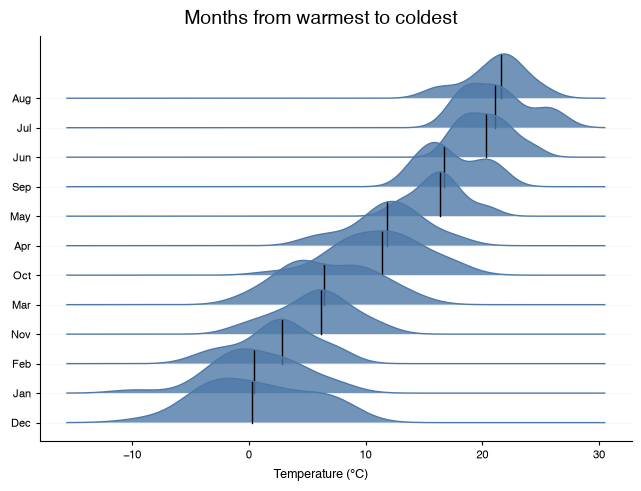

In [16]:
RidgelinePlot(
    data=chart_data,
    # the warmest month at the top
    sort=SORT.DESCENDING,
    inner=VIOLIN_INNER.MEDIAN,
    title="Months from warmest to coldest",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Bandwidth

Each ridge is a kernel density estimate of its values. The `bandwidth` attribute sets how much the estimate smooths: a rule of the [datachart.constants.BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) constant (`"scott"`, the default, or `"silverman"`) or a scalar factor, where smaller values follow the data more closely and larger ones smooth it more.

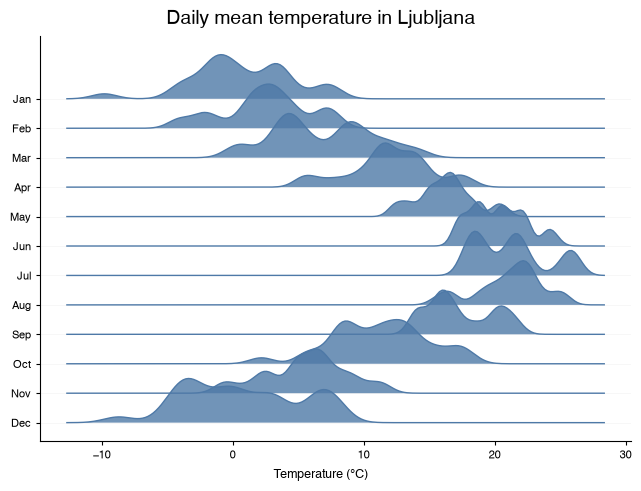

In [17]:
RidgelinePlot(
    data=chart_data,
    # a narrow bandwidth follows the thirty days closely
    bandwidth=0.25,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Value range

All ridges are evaluated on one shared grid, so the curves line up point for point. By default the grid spans every row's values, extended a little past the extremes so the tails fade out. On the value axis, `xmin` and `xmax` (`ymin` and `ymax` when the rows run vertically) also bound that grid, so the ridges stop exactly at the axis limits.

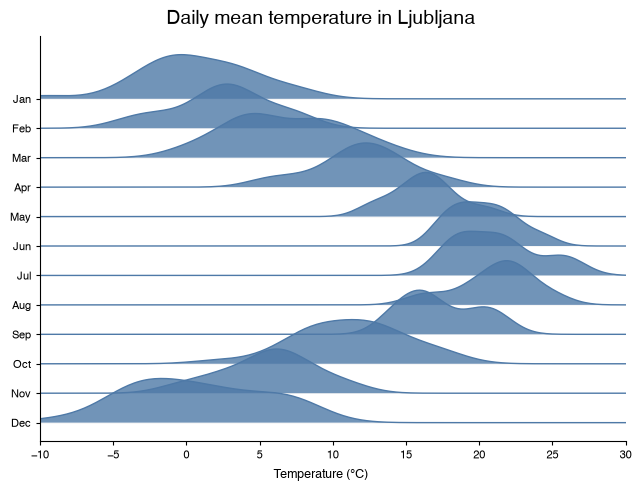

In [18]:
RidgelinePlot(
    data=chart_data,
    # the ridges and the axis both span -10 to 30 °C
    xmin=-10,
    xmax=30,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Orientation

To change the orientation, add the `orientation` attribute with a value of the [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant:

| Value | Description |
| :---- | :---------- |
| `"horizontal"` | The value axis is the x-axis and the rows stack along the y-axis, the first at the top, each ridge rising up from its tick (the default). |
| `"vertical"` | The value axis is the y-axis and the rows run along the x-axis, the first on the left, each ridge rising to the right from its tick. |

In [19]:
from datachart.constants import ORIENTATION

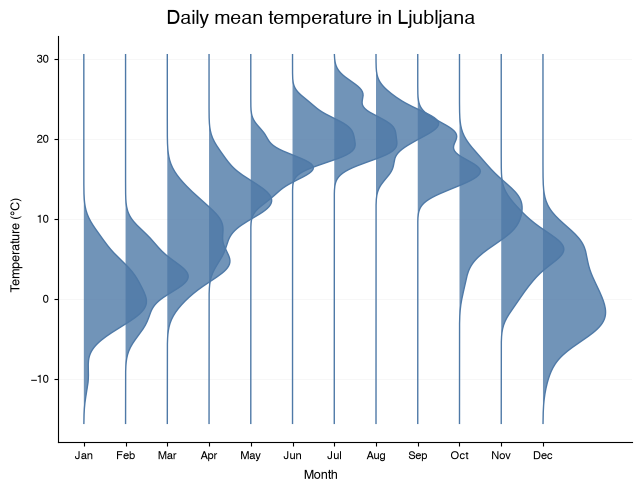

In [20]:
RidgelinePlot(
    data=chart_data,
    # transpose the chart
    orientation=ORIENTATION.VERTICAL,
    title="Daily mean temperature in Ljubljana",
    xlabel="Month",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

To draw attention to some rows, add the `emphasis` attribute. The `emphasis` list aligns with the row **labels** of one call, in the order the labels first appear in the data — here January to December — whatever the `sort`. Each entry is one of the following roles:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the ridge and its inner marks into the theme's muted color and alpha. |
| `"highlight"` | Bolds the ridge outline. |
| `None` | Leaves the row unchanged. |

A single value applies to every row. The [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant holds the roles; the [highlighting guide](../../styling/highlighting.ipynb) covers emphasis across chart types and themes.

To pick the rows from the data instead, pass `emphasis_rule`, a one-key rule — `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}` — that highlights every row whose summary matches and mutes the rest. The summary is the median of each row's values by default; a `"by"` key picks `"mean"`, `"min"`, `"max"`, or `"sum"` instead. An explicit `emphasis` role wins over the rule.

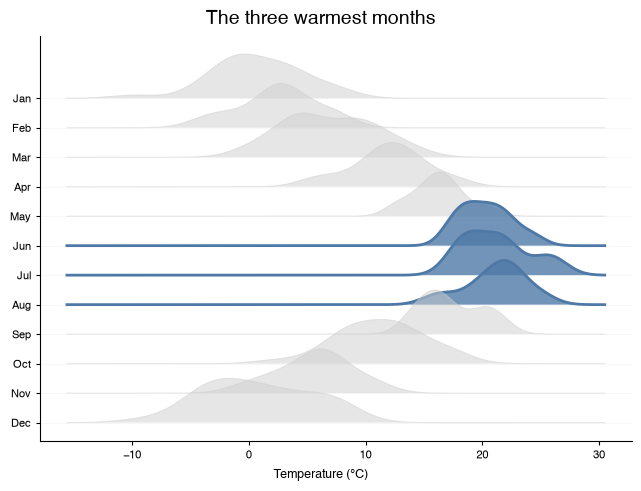

In [21]:
RidgelinePlot(
    data=chart_data,
    # highlight the three months with the warmest median, mute the rest
    emphasis_rule={"top": 3},
    title="The three warmest months",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines

A reference line puts a threshold next to the ridges. With the default orientation the value axis is the x-axis, so add vertical lines with the `vlines` attribute and the [datachart.typings.VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs) typing, and vertical bands with `vspans` and the [datachart.typings.VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) typing.

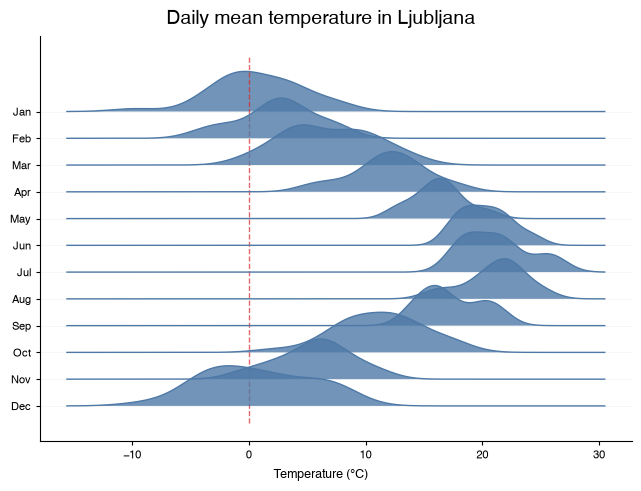

In [22]:
from datachart.constants import LINE_STYLE

RidgelinePlot(
    data=chart_data,
    # mark the freezing point
    vlines={
        "x": 0,
        "style": {"plot_vline_color": "#d62728", "plot_vline_style": LINE_STYLE.DASHED},
    },
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Ridgeline Plots

To create multiple ridgeline plots, pass a list of lists to the `data` argument. Each inner list holds the data points of one chart, and every chart draws in its own subplot. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts; `sharex` shares the value axis across the subplots. The ridges of every subplot are evaluated over one shared value range, so they span the same stretch of the axis.

Here the year is split into the cold half (October to March) and the warm half (April to September).

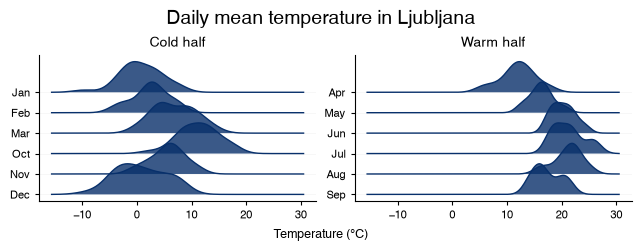

In [23]:
COLD = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar"]

halves = [
    [point for point in chart_data if point["label"] in COLD],
    [point for point in chart_data if point["label"] not in COLD],
]

RidgelinePlot(
    # use a list of lists to define multiple ridgeline plots
    data=halves,
    subtitle=["Cold half", "Warm half"],
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    # the same temperature axis for both charts
    sharex=True,
).show()

## Composing ridgelines

Each ridge sits on its row's category position, so a ridgeline figure composes like any group chart. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with a [datachart.charts.SwarmPlot](../../../references/charts/#datachart.charts.SwarmPlot) of the same labels to show every day under its month's ridge: over ridges the panel packs the swarm on the side the ridges rise to, so every day sits inside the ridge of its month. The swarm must share the horizontal orientation; a dark, small point keeps the days readable over the ridge fill. The panel keeps the first row at the top for every chart in it, and labels its axes by role: `xlabel` names the category axis and `ylabel_left` the value axis, wherever they are drawn.

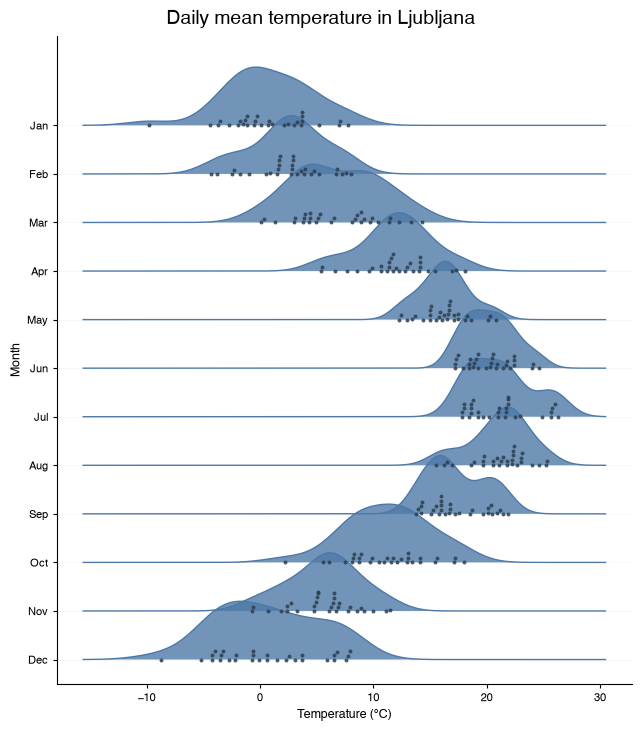

In [24]:
from datachart.charts import SwarmPlot
from datachart.utils import Panel

Panel(
    [
        RidgelinePlot(data=chart_data, overlap=0.2),
        # one point per day, on its month's row
        SwarmPlot(
            data=chart_data,
            orientation=ORIENTATION.HORIZONTAL,
            style={"plot_swarm_color": "#2C3E50", "plot_swarm_size": 8},
        ),
    ],
    title="Daily mean temperature in Ljubljana",
    # Panel labels the axes by role: the category axis, then the value axis
    xlabel="Month",
    ylabel_left="Temperature (°C)",
    figsize=FIG_SIZE.FULL_TALL,
).show()

[datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges a ridgeline next to other figures, here a horizontal [datachart.charts.BoxPlot](../../../references/charts/#datachart.charts.BoxPlot) of the same months. With `sharex` and `sharey` the two charts share both axes: the months line up row for row, and the box plot follows the ridgeline's first-row-at-the-top order.

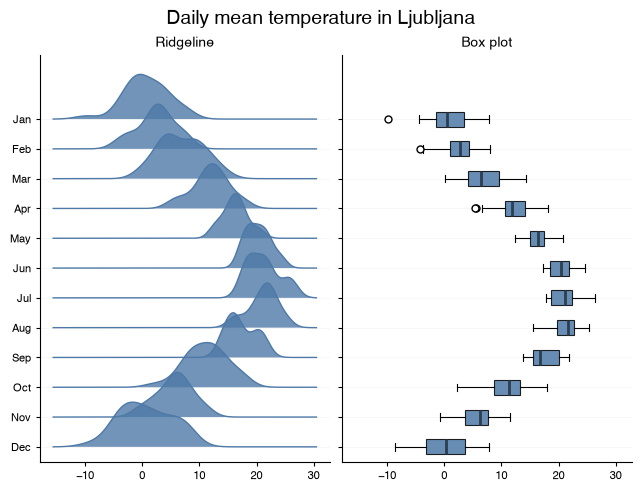

In [25]:
from datachart.charts import BoxPlot

Grid(
    [
        RidgelinePlot(data=chart_data, title="Ridgeline"),
        BoxPlot(data=chart_data, orientation=ORIENTATION.HORIZONTAL, title="Box plot"),
    ],
    title="Daily mean temperature in Ljubljana",
    # one temperature axis and one month axis for both charts
    sharex=True,
    sharey=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Additional Features

### Custom data keys

If the data points hold the label and the value under other keys, add the `label` and `value` attributes with the key names, so the data need not be reshaped.

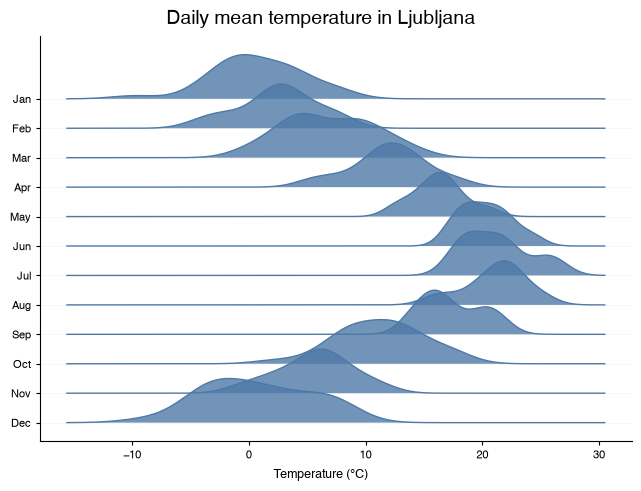

In [26]:
records = [{"month": point["label"], "celsius": point["value"]} for point in chart_data]

RidgelinePlot(
    data=records,
    # the keys holding the label and the value
    label="month",
    value="celsius",
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [27]:
from datachart.utils import save_figure

figure = RidgelinePlot(
    data=chart_data,
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
save_figure(figure, "./fig_ridgeline_plot.png", dpi=300)

['./fig_ridgeline_plot.png']

The figure should be saved in the current working directory.

## Real-World Examples

The examples below put the ridgeline plot to work on typical questions. Their data is illustrative: drawn with a fixed seed around realistic values, so every run draws the same chart.

### API latency across releases

A service team compares the response times of eight releases against a 300 ms target. The rows stay in release order, so a shift in the distribution reads as a change over time; the median marks and the rule-based emphasis point out the releases whose median crossed 200 ms, and the dashed line shows the target.

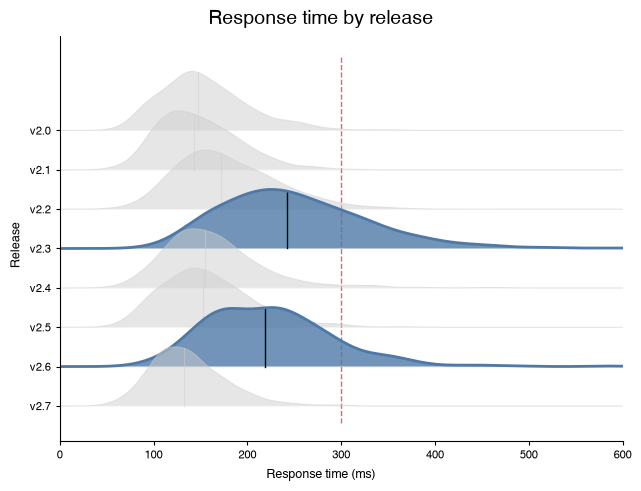

In [28]:
import numpy as np

from datachart.constants import EMPHASIS, LINE_STYLE, ORIENTATION, SORT, VIOLIN_INNER

rng = np.random.RandomState(7)
# median response time (ms) of each release; 2.3 regressed, 2.4 fixed it
RELEASES = {"2.0": 150, "2.1": 145, "2.2": 170, "2.3": 240, "2.4": 160, "2.5": 150, "2.6": 210, "2.7": 135}
latency = [
    {"label": f"v{release}", "value": round(float(ms), 1)}
    for release, median in RELEASES.items()
    for ms in rng.lognormal(np.log(median), 0.3, 400)
]

RidgelinePlot(
    data=latency,
    inner=VIOLIN_INNER.MEDIAN,
    # highlight the releases whose median crossed 200 ms
    emphasis_rule={"above": 200},
    vlines={
        "x": 300,
        "label": "target",
        "style": {"plot_vline_color": "#d62728", "plot_vline_style": LINE_STYLE.DASHED},
    },
    xmin=0,
    xmax=600,
    title="Response time by release",
    xlabel="Response time (ms)",
    ylabel="Release",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Taxi trip duration by hour of day

Twenty-four hours in the height of one chart: the classic joy plot look, with an opaque fill, a white outline, and full overlap. The two rush hours stand out as the ridges pushed to the right, and the quiet night hours as the narrow ones on the left.

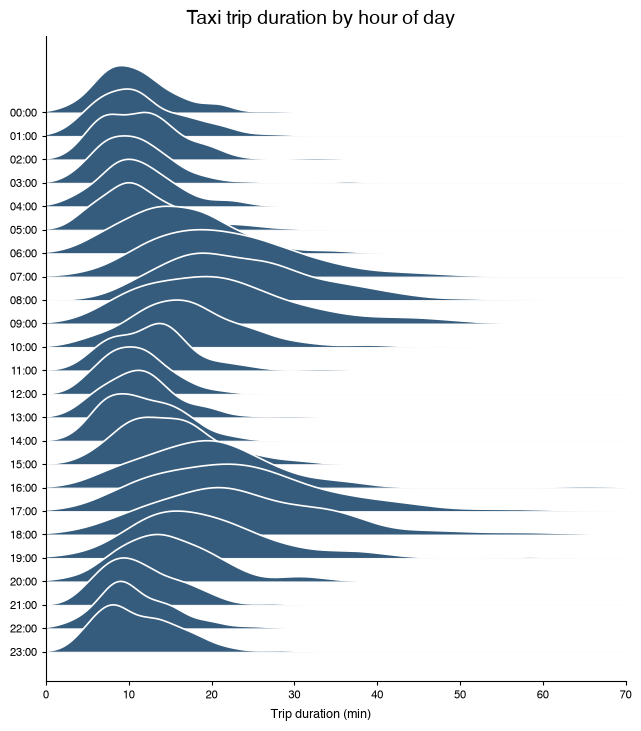

In [29]:
rng = np.random.RandomState(3)
trips = []
for hour in range(24):
    # longer, more variable trips in the morning and evening rush
    rush = np.exp(-((hour - 8) ** 2) / 4) + np.exp(-((hour - 17.5) ** 2) / 5)
    median = 11 + 14 * rush
    trips += [
        {"label": f"{hour:02d}:00", "value": round(float(minutes), 1)}
        for minutes in rng.gamma(6, median / 6, 120)
    ]

RidgelinePlot(
    data=trips,
    overlap=1.0,
    style={
        "plot_ridgeline_color": "#355C7D",
        "plot_ridgeline_alpha": 1.0,
        "plot_ridgeline_edgecolor": "#FFFFFF",
        "plot_ridgeline_linewidth": 1.2,
    },
    xmin=0,
    xmax=70,
    title="Taxi trip duration by hour of day",
    xlabel="Trip duration (min)",
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Model confidence over training

A research figure tracks how confident a classifier's predictions are on a validation set after each epoch. With `normalize="common"` the ridges share one density scale, so the distribution visibly narrows and grows taller as training sharpens it — a per-row scale would draw every epoch at the same height and hide exactly that. The outlines alone keep the later epochs visible through the overlap.

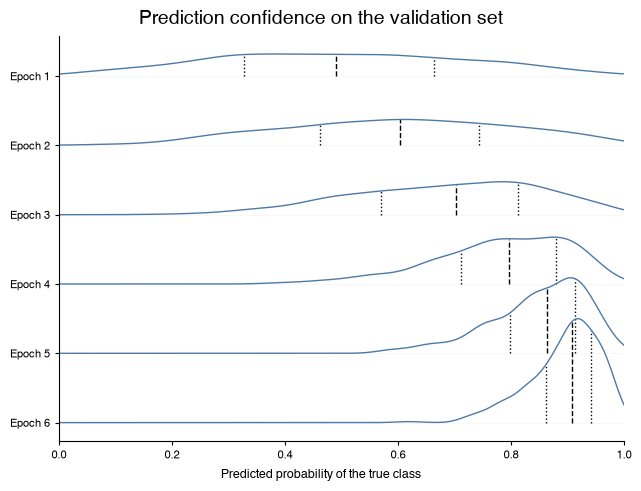

In [30]:
from datachart.constants import RIDGELINE_SCALE

rng = np.random.RandomState(5)
confidence = [
    {"label": f"Epoch {epoch}", "value": round(float(p), 3)}
    for epoch, (a, b) in enumerate([(2, 2), (3, 2), (5, 2.2), (8, 2.2), (14, 2.5), (22, 2.6)], start=1)
    for p in rng.beta(a, b, 500)
]

RidgelinePlot(
    data=confidence,
    normalize=RIDGELINE_SCALE.COMMON,
    fill=False,
    inner=VIOLIN_INNER.QUARTILES,
    xmin=0,
    xmax=1,
    title="Prediction confidence on the validation set",
    xlabel="Predicted probability of the true class",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Exam scores by school, with every student

An education report ranks eight schools by their median exam score and shows every student under their school's ridge. The rows are sorted by median, the lowest-performing school at the bottom; a strip of small points keeps several hundred students readable, and `Panel` lays the strip on the same rows.

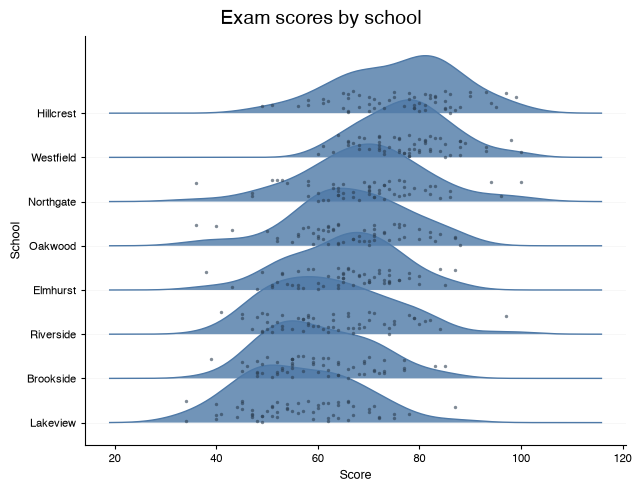

In [31]:
from datachart.charts import SwarmPlot
from datachart.constants import SWARM_MODE
from datachart.utils import Panel

rng = np.random.RandomState(12)
SCHOOLS = {"Northgate": 71, "Riverside": 64, "Hillcrest": 78, "Lakeview": 58, "Oakwood": 69, "Westfield": 74, "Brookside": 61, "Elmhurst": 66}
scores = [
    {"label": school, "value": round(float(np.clip(score, 0, 100)))}
    for school, mean in SCHOOLS.items()
    for score in rng.normal(mean, 11, 60)
]

Panel(
    [
        RidgelinePlot(data=scores, sort=SORT.DESCENDING, overlap=0.3),
        SwarmPlot(
            data=scores,
            orientation=ORIENTATION.HORIZONTAL,
            mode=SWARM_MODE.STRIP,
            jitter=0.5,
            style={"plot_swarm_color": "#2C3E50", "plot_swarm_size": 6, "plot_swarm_alpha": 0.6},
        ),
    ],
    title="Exam scores by school",
    xlabel="School",
    ylabel_left="Score",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()